In [7]:
import os
import pandas as pd

# ==========================================
# 1. LOAD MODULAR FEATURE TABLES
# ==========================================
data_dir = '../modelData'

# Load each feature store, keeping loan_id as the index
loan_df = pd.read_csv(os.path.join(data_dir, 'features_loan.csv'), index_col='loan_id')
orders_df = pd.read_csv(os.path.join(data_dir, 'features_orders.csv'), index_col='loan_id')
trans_df = pd.read_csv(os.path.join(data_dir, 'features_transaction.csv'), index_col='loan_id')
client_df = pd.read_csv(os.path.join(data_dir, 'feature_client.csv'), index_col='loan_id') # Updated for client/co-signer features

# Ensure index is string type for clean joins
loan_df.index = loan_df.index.astype(str)
orders_df.index = orders_df.index.astype(str)
trans_df.index = trans_df.index.astype(str)
client_df.index = client_df.index.astype(str) # Ensure string index for client features

# ==========================================
# 2. JOIN ALL TABLES ON loan_id
# ==========================================
# Start with loan baseline (contains contract terms and target)
master_df = loan_df.join(orders_df, how='left')

# Join transaction features
master_df = master_df.join(trans_df, how='left')

# Join client/co-signer features (includes has_co_signer)
master_df = master_df.join(client_df, how='left')

# For missing features across tables, fill with 0
master_df = master_df.fillna(0)

# ==========================================
# 3. SPLIT INTO FEATURES (X) AND TARGET (y)
# ==========================================
if 'target' in master_df.columns:
    y = master_df['target']
    X = master_df.drop(columns=['target'])
else:
    raise ValueError("Target column not found in master dataframe!")



# ==========================================
# 4. VALIDATION READOUT
# ==========================================
print("=" * 50)
print(" MASTER MODELING DATASET CREATED SUCCESSFULLY")
print(f" Total Loans (Rows):     {master_df.shape[0]}")
print(f" Total Features (Cols):  {X.shape[1]}")
print(f" Missing Values (NaN):   {master_df.isna().sum().sum()}")
print(f" Default Class Balance:  {y.sum()} defaults out of {len(y)} loans ({y.mean()*100:.2f}%)")
print("=" * 50)

 MASTER MODELING DATASET CREATED SUCCESSFULLY
 Total Loans (Rows):     682
 Total Features (Cols):  31
 Missing Values (NaN):   0
 Default Class Balance:  76 defaults out of 682 loans (11.14%)


In [8]:
master_df.columns

Index(['amount', 'duration', 'payments', 'target', 'order_count',
       'order_total_amount', 'order_mean_amount', 'order_max_amount',
       'order_amt_household_utility', 'order_amt_insurance_payment',
       'order_amt_loan_payment', 'order_amt_other_unknown', 'is_closed',
       'loan_date', 'min_balance', 'mean_balance', 'std_balance',
       'total_tx_count', 'history_days', 'total_inflow', 'total_outflow',
       'mean_balance_90d', 'freq_negative_balance', 'last_balance',
       'sanction_interest', 'cash_reliance_ratio', 'months_history',
       'avg_monthly_inflow', 'tx_per_month', 'dsti_ratio', 'balance_trend_90d',
       'has_co_signer'],
      dtype='str')

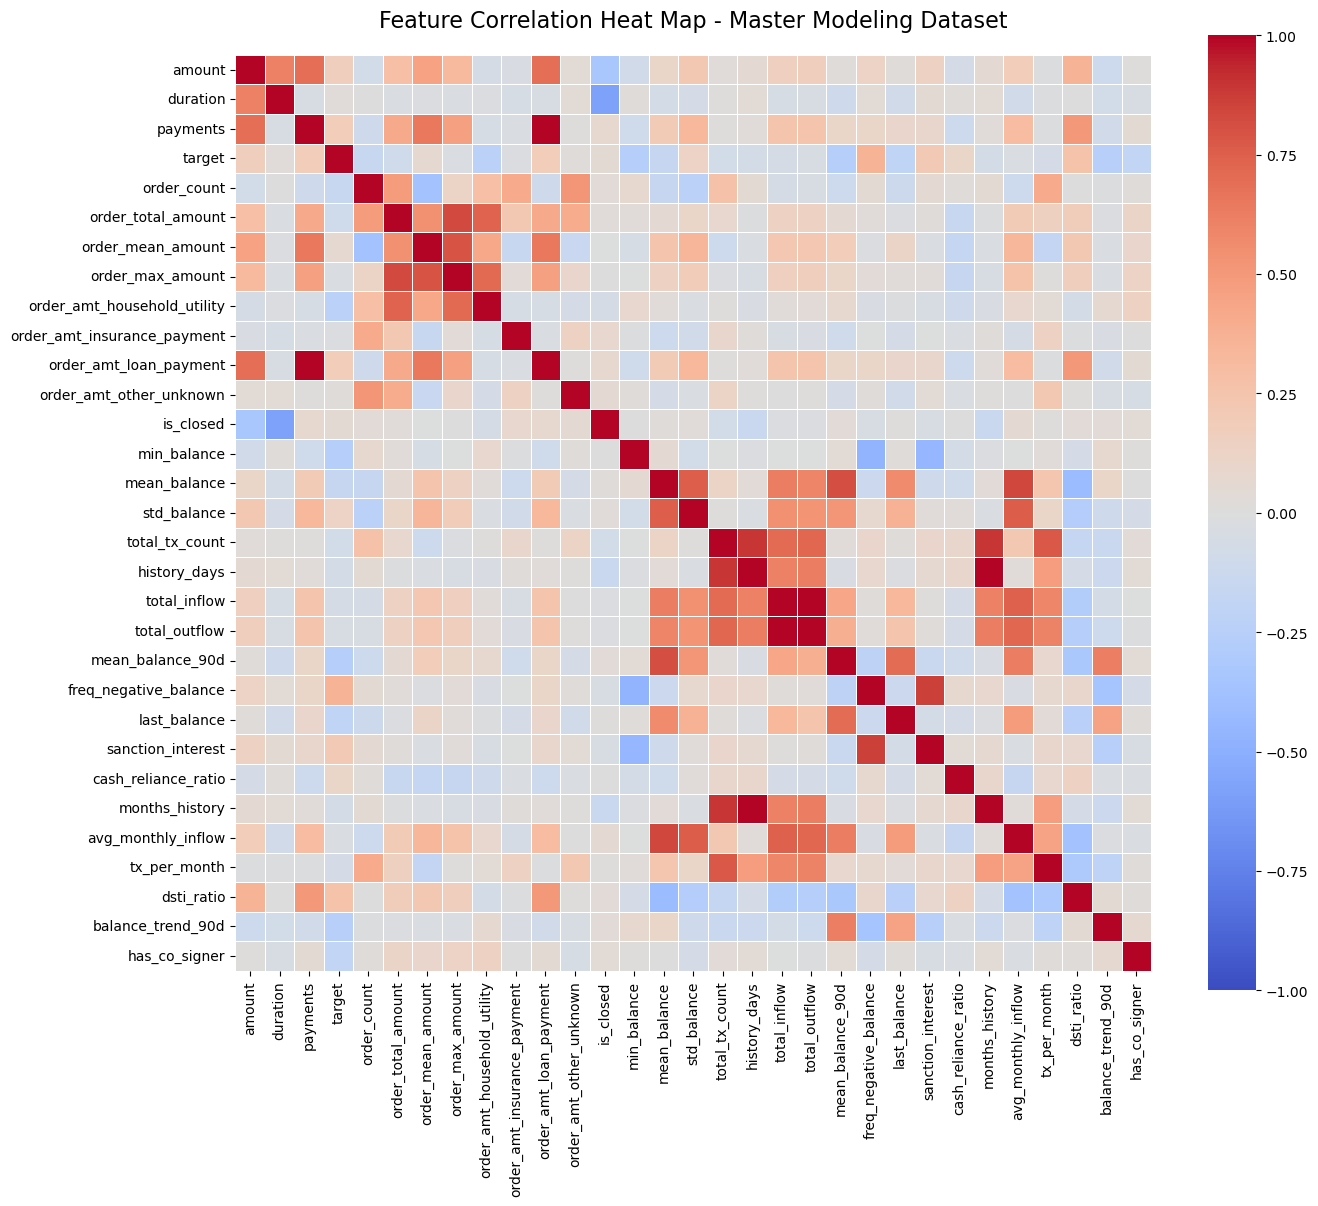

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 5. CORRELATION HEAT MAP VISUALIZATION
# ==========================================

# Select only numeric columns for correlation calculation
numeric_df = master_df.select_dtypes(include=['number'])

# Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(14, 12))

# Draw the heatmap using seaborn
sns.heatmap(
    corr_matrix, 
    annot=False,           # Set to True if you want numbers inside cells (can get crowded with 31 features)
    cmap='coolwarm',       # Color map (blue for negative, red for positive correlation)
    vmin=-1, vmax=1,       # Fix scale from -1 to 1
    linewidths=0.5,        # Grid lines between cells
    square=True            # Ensure square aspect ratio
)

# Title and formatting
plt.title('Feature Correlation Heat Map - Master Modeling Dataset', fontsize=16, pad=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)

# Display the plot
plt.tight_layout()
plt.show()

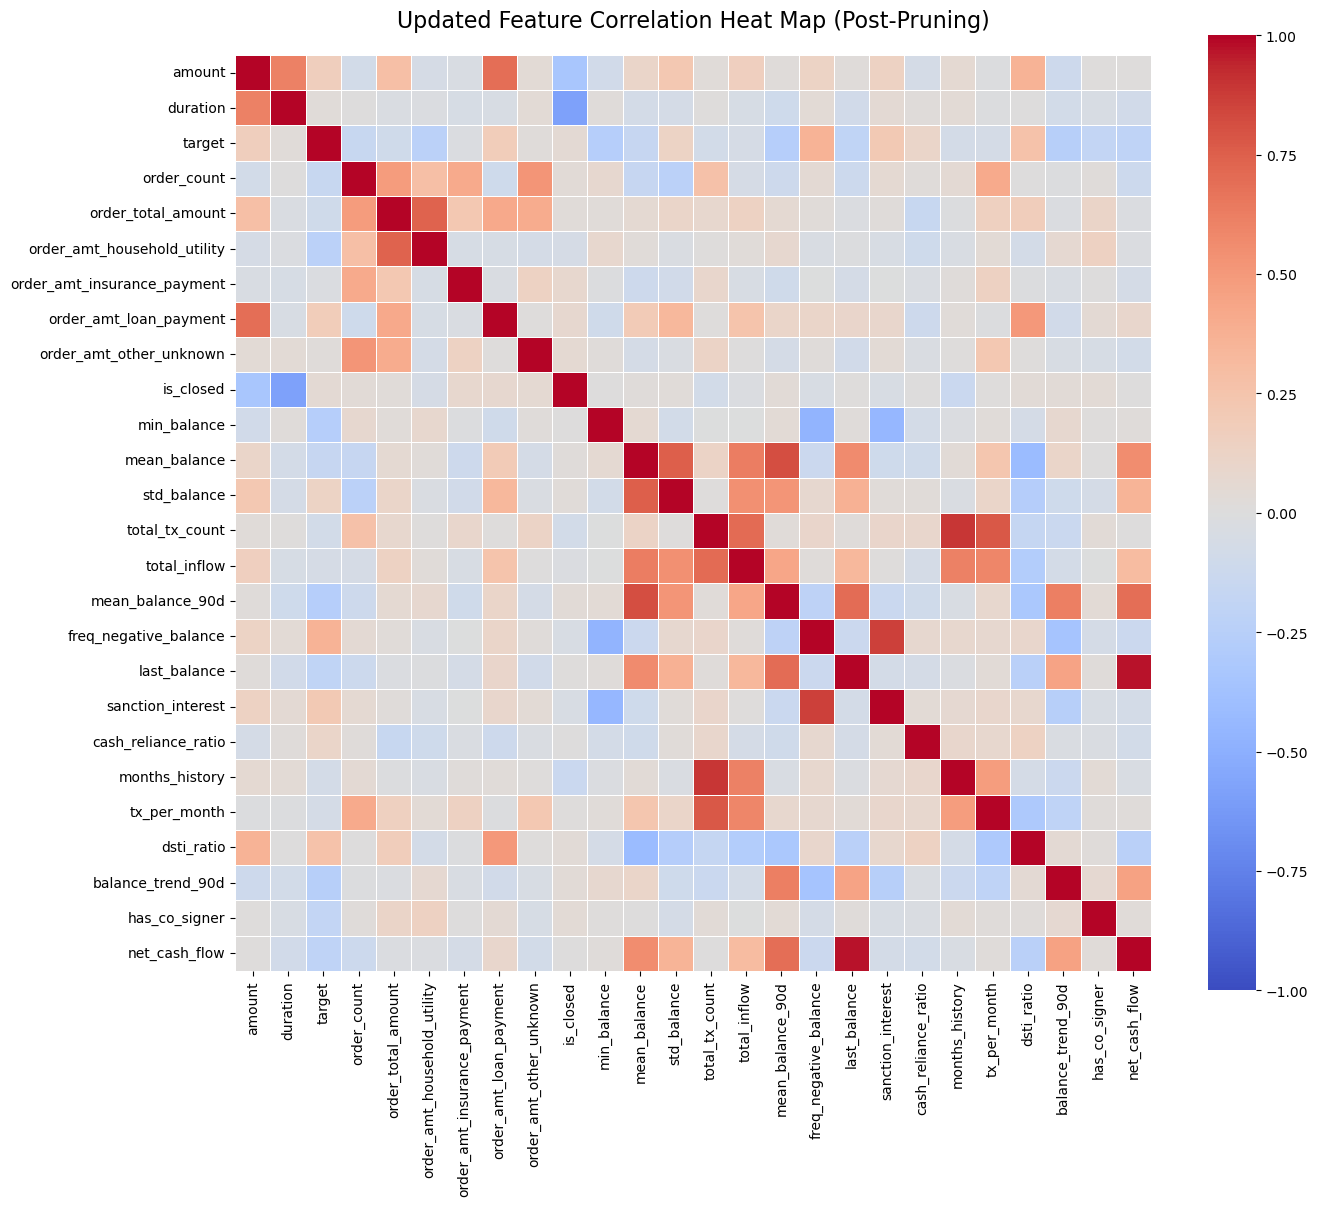

Updated dataset shape after dropping columns: (682, 27)


In [10]:
# ==========================================
# 6. FEATURE PRUNING & RE-MAPPING
# ==========================================

# Combine total_outflow with the additional redundant features to remove
features_to_drop_after_heatmap = [
    'total_outflow', 
    'payments', 
    'order_mean_amount', 
    'order_max_amount', 
    'history_days', 
    'avg_monthly_inflow'
]

if 'total_inflow' in master_df.columns and 'total_outflow' in master_df.columns:
    # Optional: Engineer a net cash flow metric before dropping
    master_df['net_cash_flow'] = master_df['total_inflow'] - master_df['total_outflow']

# Drop the unwanted columns safely
master_df = master_df.drop(columns=[col for col in features_to_drop_after_heatmap if col in master_df.columns])

# Recalculate correlation matrix with the reduced feature set
numeric_df_reduced = master_df.select_dtypes(include=['number'])
corr_matrix_reduced = numeric_df_reduced.corr()

# Plot the updated heat map
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix_reduced, 
    annot=False,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True
)

plt.title('Updated Feature Correlation Heat Map (Post-Pruning)', fontsize=16, pad=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"Updated dataset shape after dropping columns: {master_df.shape}")

In [11]:
master_output_path = os.path.join(data_dir, 'master_modeling_matrix.csv')
master_df.to_csv(master_output_path)